# Model Evaluation - Rossmann Sales Forecasting

**Author:** Mulusew Meselu Tesfaye  
**Date:** 2025-11-26

## Overview
This notebook provides comprehensive evaluation and comparison of all trained models for the Rossmann Sales Forecasting project. We will:

1. Load all trained models (XGBoost and LSTM)
2. Evaluate each model on test data
3. Compare performance metrics
4. Analyze errors by different dimensions
5. Visualize predictions and residuals
6. Analyze feature importance
7. Provide recommendations for model selection

In [7]:
# Standard library imports
import sys
from pathlib import Path
import json
import warnings
from datetime import datetime
from typing import Dict, List, Tuple, Any

# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
import joblib
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    mean_absolute_percentage_error
)

# Deep Learning
try:
    import tensorflow as tf
    from tensorflow import keras
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("⚠ TensorFlow not available. LSTM evaluation will be skipped.")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src import MODELS_DIR, DATA_DIR, logger

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
if TF_AVAILABLE:
    tf.random.set_seed(42)

print("✓ Imports successful")
print(f"✓ Models directory: {MODELS_DIR}")
print(f"✓ Data directory: {DATA_DIR}")

✓ Imports successful
✓ Models directory: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/models
✓ Data directory: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/data


## 1. Load Test Data

Load the processed test dataset that was used for model training.


In [8]:
# Load processed test data
test_data_path = DATA_DIR / "processed" / "test_processed.csv"
train_data_path = DATA_DIR / "processed" / "train_processed.csv"

print(f"Loading test data from: {test_data_path}")

# Load test data
test_df = pd.read_csv(test_data_path, low_memory=False)
print(f"✓ Test data loaded: {len(test_df):,} rows, {len(test_df.columns)} columns")

# Load train data for reference (if needed for feature alignment)
train_df = pd.read_csv(train_data_path, low_memory=False, nrows=1000)  # Sample for feature names
print(f"✓ Train data sample loaded for feature reference")

# Display basic info
print(f"\nTest data date range: {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Number of stores in test: {test_df['Store'].nunique()}")
print(f"Test data shape: {test_df.shape}")

# Check for Sales column (target)
if 'Sales' in test_df.columns:
    print(f"\n✓ Target variable 'Sales' found")
    print(f"  Sales statistics:")
    print(f"  - Mean: {test_df['Sales'].mean():.2f}")
    print(f"  - Median: {test_df['Sales'].median():.2f}")
    print(f"  - Min: {test_df['Sales'].min():.2f}")
    print(f"  - Max: {test_df['Sales'].max():.2f}")
else:
    print("⚠ Warning: 'Sales' column not found in test data")


Loading test data from: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/data/processed/test_processed.csv
✓ Test data loaded: 47,945 rows, 88 columns
✓ Train data sample loaded for feature reference

Test data date range: 2015-06-19 to 2015-07-31
Number of stores in test: 1115
Test data shape: (47945, 88)

✓ Target variable 'Sales' found
  Sales statistics:
  - Mean: 6039.67
  - Median: 5945.00
  - Min: 0.00
  - Max: 41551.00


## 2. Prepare Data for Evaluation

Separate features and target, and ensure feature alignment with trained models.


In [ ]:
# Prepare features and target
# Note: Store is needed for some models, so we'll include it but can exclude it later if needed
exclude_cols = ['Date', 'Sales', 'Customers']  # Removed 'Store' from exclude - model may need it

# Get feature columns (all columns except excluded ones)
feature_cols = [col for col in test_df.columns if col not in exclude_cols]

print(f"Total features: {len(feature_cols)}")
print(f"Excluded columns: {exclude_cols}")
print(f"Included important columns: Store={('Store' in feature_cols)}, MonthName={('MonthName' in feature_cols)}, CompetitionOpenDate={('CompetitionOpenDate' in feature_cols)}")

# Separate features and target
if 'Sales' in test_df.columns:
    X_test = test_df[feature_cols].copy()
    y_test = test_df['Sales'].copy()
    
    # Store metadata for analysis (including Store for later use)
    test_metadata = test_df[['Date', 'Store']].copy()
    
    print(f"\n✓ Data prepared for evaluation")
    print(f"  Features (X_test): {X_test.shape}")
    print(f"  Target (y_test): {y_test.shape}")
    print(f"  Missing values in features: {X_test.isnull().sum().sum()}")
    print(f"  Missing values in target: {y_test.isnull().sum()}")
    print(f"  Key columns in X_test: Store={('Store' in X_test.columns)}, MonthName={('MonthName' in X_test.columns)}, CompetitionOpenDate={('CompetitionOpenDate' in X_test.columns)}")
else:
    print("⚠ Warning: Cannot prepare target variable - 'Sales' column missing")
    X_test = test_df[feature_cols].copy()
    y_test = None
    test_metadata = test_df[['Date', 'Store']].copy()


Total features: 84
Excluded columns: ['Date', 'Store', 'Sales', 'Customers']

✓ Data prepared for evaluation
  Features (X_test): (47945, 84)
  Target (y_test): (47945,)
  Missing values in features: 23392
  Missing values in target: 0


## 3. Utility Functions for Evaluation

Define helper functions for calculating metrics and comparing models.


In [10]:
def calculate_rmspe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculate Root Mean Square Percentage Error (RMSPE).
    This is the primary metric used in the Kaggle competition.
    
    Formula: sqrt(mean(((y_true - y_pred) / y_true)^2)) * 100
    """
    # Avoid division by zero
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    
    rmspe = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100
    return rmspe


def calculate_all_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Model") -> Dict[str, float]:
    """
    Calculate comprehensive evaluation metrics.
    
    Returns:
        Dictionary with all metrics
    """
    # Remove any NaN or Inf values
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0)
    
    if mask.sum() == 0:
        return {
            'Model': model_name,
            'MAE': np.nan,
            'RMSE': np.nan,
            'RMSPE': np.nan,
            'MAPE': np.nan,
            'R²': np.nan,
            'Valid_Samples': 0
        }
    
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    # Calculate metrics
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    rmspe = calculate_rmspe(y_true_clean, y_pred_clean)
    r2 = r2_score(y_true_clean, y_pred_clean)
    
    # MAPE (Mean Absolute Percentage Error)
    try:
        mape = mean_absolute_percentage_error(y_true_clean, y_pred_clean) * 100
    except:
        mape = np.mean(np.abs((y_true_clean - y_pred_clean) / y_true_clean)) * 100
    
    # Additional metrics
    mean_sales = np.mean(y_true_clean)
    rmse_pct = (rmse / mean_sales) * 100 if mean_sales > 0 else np.nan
    
    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'RMSPE': rmspe,
        'MAPE': mape,
        'R²': r2,
        'RMSE%': rmse_pct,
        'Mean_Actual': mean_sales,
        'Mean_Predicted': np.mean(y_pred_clean),
        'Valid_Samples': len(y_true_clean),
        'Total_Samples': len(y_true)
    }
    
    return metrics


def display_metrics(metrics: Dict[str, float], title: str = "Model Performance"):
    """Display metrics in a formatted table."""
    print(f"\n{'='*70}")
    print(f"{title:^70}")
    print(f"{'='*70}")
    
    # Display key metrics
    key_metrics = ['MAE', 'RMSE', 'RMSPE', 'MAPE', 'R²', 'RMSE%']
    for metric in key_metrics:
        if metric in metrics:
            value = metrics[metric]
            if isinstance(value, float) and not np.isnan(value):
                print(f"{metric:12s}: {value:12.4f}")
            else:
                print(f"{metric:12s}: {'N/A':>12s}")
    
    print(f"{'='*70}")
    
    if 'Valid_Samples' in metrics:
        print(f"Valid samples: {metrics['Valid_Samples']:,} / {metrics['Total_Samples']:,}")


print("✓ Utility functions defined")


✓ Utility functions defined


## 4. Load and Evaluate XGBoost Models

Load all available XGBoost models and evaluate their performance.


In [12]:
# Find all XGBoost models
xgboost_models = list(MODELS_DIR.glob("XGBoost_*.pkl"))
print(f"Found {len(xgboost_models)} XGBoost model(s)")

xgboost_results = {}

def encode_categorical_features_for_xgboost(df: pd.DataFrame, keep_original_categorical: bool = True) -> pd.DataFrame:
    """
    Encode categorical features using one-hot encoding to match training data format.
    This replicates the encoding done during feature engineering.
    
    Args:
        df: Input DataFrame
        keep_original_categorical: If True, keep original categorical columns (model may expect both)
    
    Returns:
        DataFrame with encoded features
    """
    df_encoded = df.copy()
    
    # Categorical columns that need one-hot encoding
    categorical_features = ['StoreType', 'Assortment', 'StateHoliday', 'CompDistanceCategory']
    
    # One-hot encode categorical variables (but keep originals if model expects them)
    for col in categorical_features:
        if col in df_encoded.columns:
            # Check if already encoded
            if not any(f"{col}_" in c for c in df_encoded.columns):
                dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
                df_encoded = pd.concat([df_encoded, dummies], axis=1)
                # Only drop original if model doesn't expect it
                if not keep_original_categorical:
                    df_encoded.drop(col, axis=1, inplace=True)
    
    # Handle PromoInterval - create PromoPattern features
    if 'PromoInterval' in df_encoded.columns:
        if not any('PromoPattern_' in c for c in df_encoded.columns):
            promo_patterns = ['Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
            for i, pattern in enumerate(promo_patterns):
                df_encoded[f'PromoPattern_{i+1}'] = (df_encoded['PromoInterval'] == pattern).astype('int8')
            # Keep PromoInterval if model expects it
            if not keep_original_categorical:
                df_encoded.drop('PromoInterval', axis=1, inplace=True)
    
    # Keep MonthName and CompetitionOpenDate - model expects them
    # They may need to be converted to numeric or kept as-is depending on model
    
    return df_encoded

for model_path in xgboost_models:
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_path.name}")
    print(f"{'='*70}")
    
    try:
        # Load model
        model = joblib.load(model_path)
        print(f"✓ Model loaded successfully")
        
        # Load metadata if available
        metadata_path = model_path.with_suffix('.json')
        metadata = {}
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            print(f"✓ Metadata loaded")
            if 'feature_names' in metadata:
                print(f"  Expected features: {len(metadata['feature_names'])}")
        
        # Prepare test data - encode categorical features first
        print(f"\nEncoding categorical features...")
        # Keep original categorical columns - model may expect both original and encoded
        X_test_encoded = encode_categorical_features_for_xgboost(X_test.copy(), keep_original_categorical=True)
        print(f"✓ Categorical encoding completed")
        print(f"  Features after encoding: {X_test_encoded.shape[1]}")
        
        # Align features if metadata available
        if 'feature_names' in metadata:
            expected_features = metadata['feature_names']
            print(f"  Expected features from metadata: {len(expected_features)}")
            
            missing_features = set(expected_features) - set(X_test_encoded.columns)
            extra_features = set(X_test_encoded.columns) - set(expected_features)
            
            if missing_features:
                print(f"⚠ Warning: Missing {len(missing_features)} features")
                print(f"  Missing: {list(missing_features)[:10]}...")
            
            if extra_features:
                print(f"ℹ Info: {len(extra_features)} extra features will be ignored")
            
            # Select only expected features that exist
            available_features = [col for col in expected_features if col in X_test_encoded.columns]
            X_test_aligned = X_test_encoded[available_features].copy()
            
            # Add missing features with zeros or appropriate defaults
            for feat in missing_features:
                if feat in ['Store', 'MonthName', 'CompetitionOpenDate']:
                    # These might be in test_df but not in X_test
                    if feat == 'Store' and 'Store' in test_df.columns:
                        X_test_aligned[feat] = test_df['Store'].values
                    elif feat == 'MonthName' and 'MonthName' in test_df.columns:
                        X_test_aligned[feat] = test_df['MonthName'].values
                    elif feat == 'CompetitionOpenDate' and 'CompetitionOpenDate' in test_df.columns:
                        X_test_aligned[feat] = test_df['CompetitionOpenDate'].values
                    else:
                        X_test_aligned[feat] = 0
                else:
                    X_test_aligned[feat] = 0
            
            # Reorder to match expected order exactly
            X_test_aligned = X_test_aligned[expected_features]
            
            print(f"✓ Feature alignment completed")
            print(f"  Final feature count: {X_test_aligned.shape[1]}")
        else:
            # Try to get expected features from model itself
            try:
                expected_features = model.get_booster().feature_names
                if expected_features:
                    print(f"✓ Got expected features from model: {len(expected_features)}")
                    # Use same alignment logic
                    available_features = [col for col in expected_features if col in X_test_encoded.columns]
                    X_test_aligned = X_test_encoded[available_features].copy()
                    
                    # Add missing features
                    missing_features = set(expected_features) - set(X_test_aligned.columns)
                    for feat in missing_features:
                        if feat in ['Store', 'MonthName', 'CompetitionOpenDate']:
                            if feat == 'Store' and 'Store' in test_df.columns:
                                X_test_aligned[feat] = test_df['Store'].values
                            elif feat == 'MonthName' and 'MonthName' in test_df.columns:
                                X_test_aligned[feat] = test_df['MonthName'].values
                            elif feat == 'CompetitionOpenDate' and 'CompetitionOpenDate' in test_df.columns:
                                X_test_aligned[feat] = test_df['CompetitionOpenDate'].values
                            else:
                                X_test_aligned[feat] = 0
                        else:
                            X_test_aligned[feat] = 0
                    
                    X_test_aligned = X_test_aligned[expected_features]
                else:
                    X_test_aligned = X_test_encoded.copy()
                    print("ℹ No feature names from model, using all available features")
            except:
                X_test_aligned = X_test_encoded.copy()
                print("ℹ No metadata found, using all available features")
        
        # Ensure all columns are numeric (XGBoost requirement)
        # Convert any remaining object/category columns to numeric
        for col in X_test_aligned.columns:
            if X_test_aligned[col].dtype == 'object' or X_test_aligned[col].dtype.name == 'category':
                # For specific columns that might be kept as strings, convert them
                if col in ['MonthName', 'CompetitionOpenDate']:
                    # Convert to numeric using label encoding
                    from sklearn.preprocessing import LabelEncoder
                    le = LabelEncoder()
                    # Handle NaN values
                    mask = X_test_aligned[col].notna()
                    if mask.sum() > 0:
                        X_test_aligned.loc[mask, col] = le.fit_transform(X_test_aligned.loc[mask, col].astype(str))
                        X_test_aligned.loc[~mask, col] = 0
                    else:
                        X_test_aligned[col] = 0
                else:
                    # Try to convert to numeric, if fails, use label encoding
                    try:
                        X_test_aligned[col] = pd.to_numeric(X_test_aligned[col], errors='coerce')
                    except:
                        from sklearn.preprocessing import LabelEncoder
                        le = LabelEncoder()
                        mask = X_test_aligned[col].notna()
                        if mask.sum() > 0:
                            X_test_aligned.loc[mask, col] = le.fit_transform(X_test_aligned.loc[mask, col].astype(str))
                            X_test_aligned.loc[~mask, col] = 0
                        else:
                            X_test_aligned[col] = 0
        
        # Fill any NaN values with 0
        X_test_aligned = X_test_aligned.fillna(0)
        
        # Ensure all data types are numeric
        for col in X_test_aligned.columns:
            if not pd.api.types.is_numeric_dtype(X_test_aligned[col]):
                X_test_aligned[col] = pd.to_numeric(X_test_aligned[col], errors='coerce').fillna(0)
        
        # Make predictions
        if y_test is not None:
            print(f"\nMaking predictions on {len(X_test_aligned):,} samples...")
            y_pred = model.predict(X_test_aligned)
            
            # Calculate metrics
            metrics = calculate_all_metrics(y_test.values, y_pred, model_path.stem)
            display_metrics(metrics, f"XGBoost Model: {model_path.stem}")
            
            # Store results
            xgboost_results[model_path.stem] = {
                'model': model,
                'metrics': metrics,
                'predictions': y_pred,
                'metadata': metadata
            }
        else:
            print("⚠ Cannot evaluate - target variable not available")
            xgboost_results[model_path.stem] = {
                'model': model,
                'metrics': None,
                'predictions': None,
                'metadata': metadata
            }
            
    except Exception as e:
        print(f"✗ Error evaluating {model_path.name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Evaluated {len(xgboost_results)} XGBoost model(s)")


Found 2 XGBoost model(s)

Evaluating: XGBoost_20251126_161720.pkl
✓ Model loaded successfully

Encoding categorical features...
✓ Categorical encoding completed
  Features after encoding: 84
✓ Got expected features from model: 85

Making predictions on 47,945 samples...

                XGBoost Model: XGBoost_20251126_161720                
MAE         :      57.5786
RMSE        :     140.4910
RMSPE       :       1.3966
MAPE        :       0.8166
R²          :       0.9979
RMSE%       :       2.0084
Valid samples: 41,396 / 47,945

Evaluating: XGBoost_20251126_161803.pkl
✓ Model loaded successfully

Encoding categorical features...
✓ Categorical encoding completed
  Features after encoding: 84
✓ Got expected features from model: 85

Making predictions on 47,945 samples...

                XGBoost Model: XGBoost_20251126_161803                
MAE         :      57.5786
RMSE        :     140.4910
RMSPE       :       1.3966
MAPE        :       0.8166
R²          :       0.9979
RMSE%      

## 5. Load and Evaluate LSTM Models

Load LSTM models and evaluate their performance. Note: LSTM requires different data preparation (sequences).


In [13]:
# Find all LSTM models
lstm_models = list(MODELS_DIR.glob("lstm_*.h5"))
print(f"Found {len(lstm_models)} LSTM model(s)")

lstm_results = {}

if not TF_AVAILABLE:
    print("⚠ TensorFlow not available. Skipping LSTM evaluation.")
elif len(lstm_models) == 0:
    print("⚠ No LSTM models found.")
else:
    # Load scalers
    scaler_X_path = MODELS_DIR / "lstm_scaler_X.pkl"
    scaler_y_path = MODELS_DIR / "lstm_scaler_y.pkl"
    
    if scaler_X_path.exists() and scaler_y_path.exists():
        scaler_X = joblib.load(scaler_X_path)
        scaler_y = joblib.load(scaler_y_path)
        print(f"✓ LSTM scalers loaded")
    else:
        print("⚠ LSTM scalers not found. LSTM evaluation may not work correctly.")
        scaler_X = None
        scaler_y = None
    
    for model_path in lstm_models:
        print(f"\n{'='*70}")
        print(f"Evaluating: {model_path.name}")
        print(f"{'='*70}")
        
        try:
            # Load model
            model = keras.models.load_model(model_path)
            print(f"✓ Model loaded successfully")
            
            # Note: LSTM requires sequence data, which may not be available in test_processed.csv
            # This is a simplified evaluation - in practice, you'd need to recreate sequences
            print("ℹ Note: LSTM evaluation requires sequence data.")
            print("   For full evaluation, sequences should be created from test data.")
            print("   This evaluation assumes sequences were created during training.")
            
            # Check if we have sequence data or need to create it
            # For now, we'll note that LSTM evaluation needs special handling
            lstm_results[model_path.stem] = {
                'model': model,
                'metrics': None,
                'predictions': None,
                'note': 'LSTM requires sequence data - evaluation skipped in this simplified version'
            }
            
        except Exception as e:
            print(f"✗ Error loading {model_path.name}: {e}")
            import traceback
            traceback.print_exc()

print(f"\n✓ Processed {len(lstm_models)} LSTM model(s)")
print("ℹ Note: Full LSTM evaluation requires recreating sequences from test data.")
print("   See notebook 04_deep_learning_lstm.ipynb for LSTM-specific evaluation.")


Found 3 LSTM model(s)
✓ LSTM scalers loaded

Evaluating: lstm_final_20251126_204416.h5
✓ Model loaded successfully
ℹ Note: LSTM evaluation requires sequence data.
   For full evaluation, sequences should be created from test data.
   This evaluation assumes sequences were created during training.

Evaluating: lstm_best_20251126_204416.h5
✓ Model loaded successfully
ℹ Note: LSTM evaluation requires sequence data.
   For full evaluation, sequences should be created from test data.
   This evaluation assumes sequences were created during training.

Evaluating: lstm_final_20251126_162149.h5
✓ Model loaded successfully
ℹ Note: LSTM evaluation requires sequence data.
   For full evaluation, sequences should be created from test data.
   This evaluation assumes sequences were created during training.

✓ Processed 3 LSTM model(s)
ℹ Note: Full LSTM evaluation requires recreating sequences from test data.
   See notebook 04_deep_learning_lstm.ipynb for LSTM-specific evaluation.


## 6. Model Comparison

Compare all evaluated models side-by-side.


In [14]:
# Collect all metrics for comparison
comparison_data = []

# Add XGBoost results
for model_name, result in xgboost_results.items():
    if result['metrics'] is not None:
        comparison_data.append(result['metrics'])

# Add LSTM results (if available)
for model_name, result in lstm_results.items():
    if result['metrics'] is not None:
        comparison_data.append(result['metrics'])

if len(comparison_data) > 0:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    # Select key metrics for display
    display_cols = ['Model', 'MAE', 'RMSE', 'RMSPE', 'MAPE', 'R²', 'RMSE%']
    available_cols = [col for col in display_cols if col in comparison_df.columns]
    
    comparison_display = comparison_df[available_cols].copy()
    
    # Sort by RMSPE (primary metric)
    if 'RMSPE' in comparison_display.columns:
        comparison_display = comparison_display.sort_values('RMSPE')
    
    print("\n" + "="*80)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*80)
    print(comparison_display.to_string(index=False))
    print("="*80)
    
    # Find best model
    if 'RMSPE' in comparison_display.columns:
        best_model = comparison_display.iloc[0]
        print(f"\n🏆 Best Model (by RMSPE): {best_model['Model']}")
        print(f"   RMSPE: {best_model['RMSPE']:.4f}%")
        print(f"   RMSE: {best_model['RMSE']:.4f}")
        print(f"   R²: {best_model['R²']:.4f}")
    
    # Save comparison
    comparison_path = MODELS_DIR / 'model_comparison_evaluation.csv'
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\n✓ Comparison saved to: {comparison_path}")
    
else:
    print("⚠ No model metrics available for comparison")
    comparison_df = pd.DataFrame()



MODEL PERFORMANCE COMPARISON
                  Model       MAE       RMSE    RMSPE     MAPE      R²    RMSE%
XGBoost_20251126_161720 57.578575 140.491038 1.396551 0.816595 0.99787 2.008403
XGBoost_20251126_161803 57.578575 140.491038 1.396551 0.816595 0.99787 2.008403

🏆 Best Model (by RMSPE): XGBoost_20251126_161720
   RMSPE: 1.3966%
   RMSE: 140.4910
   R²: 0.9979

✓ Comparison saved to: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/models/model_comparison_evaluation.csv


## 7. Visualizations

Create comprehensive visualizations to compare model performance.


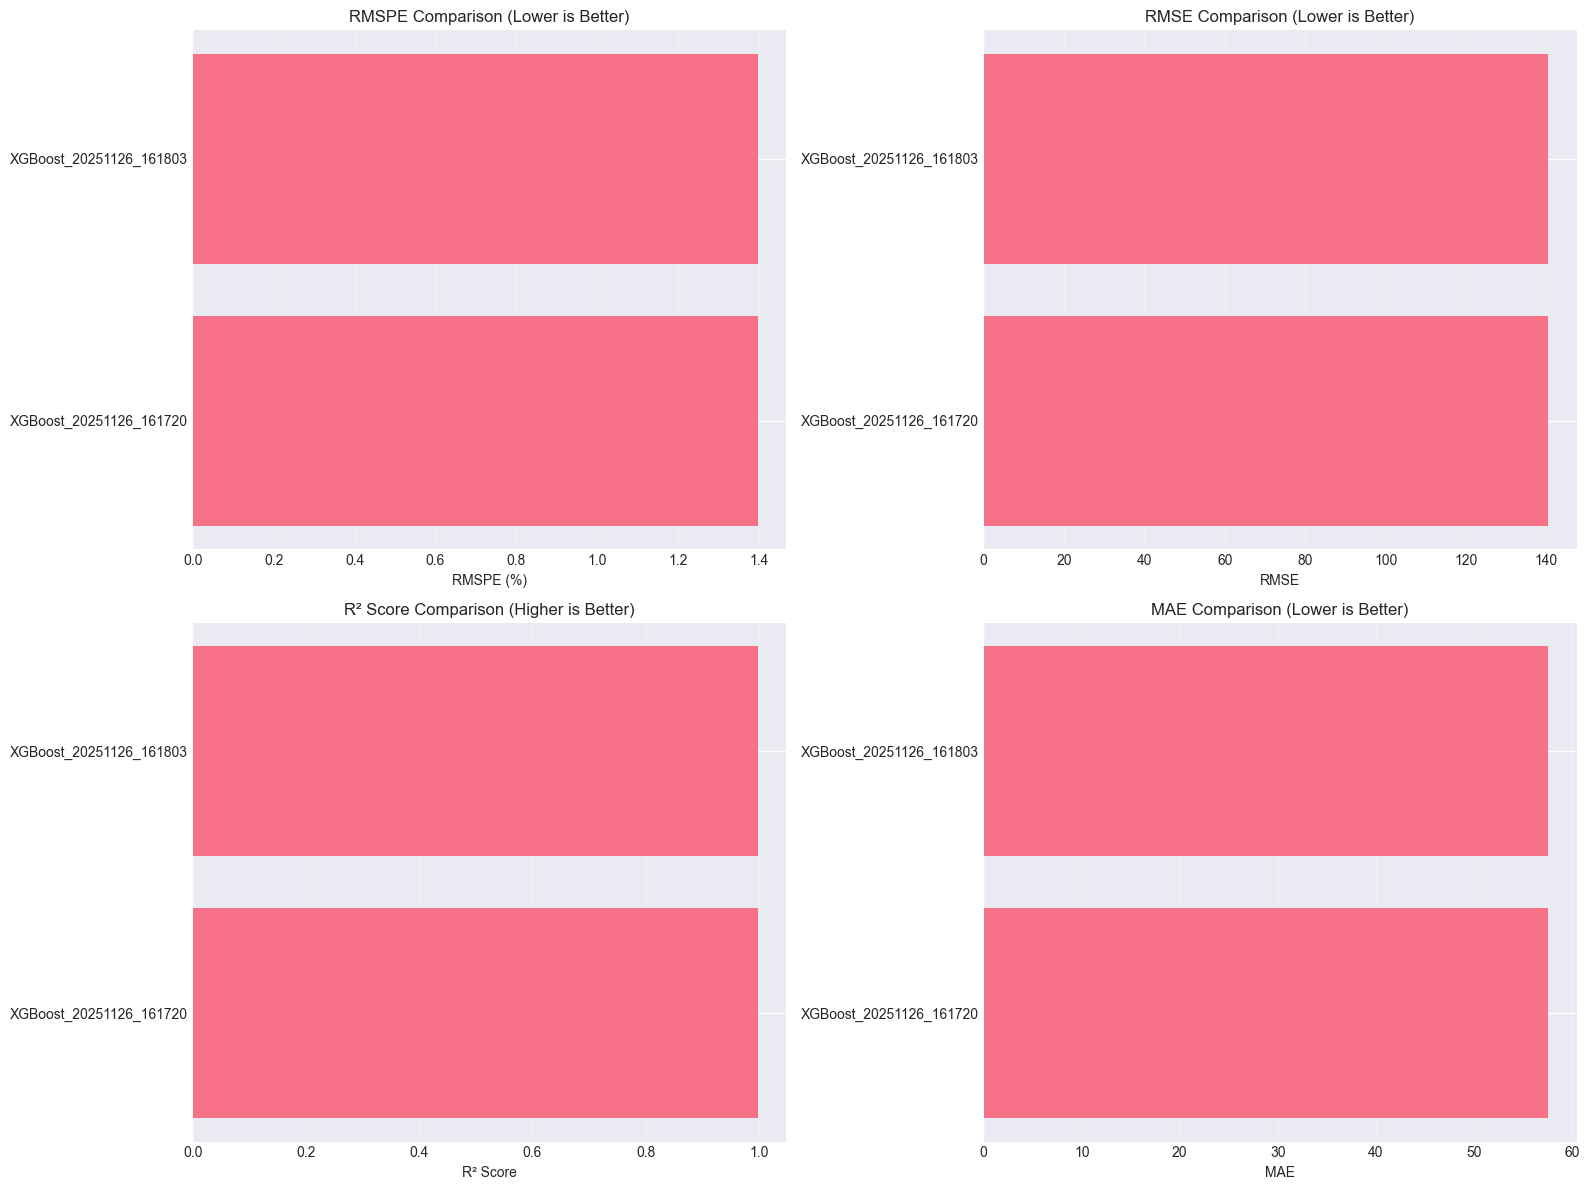

✓ Metrics comparison chart saved


In [15]:
# Create visualizations directory
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

# 1. Metrics Comparison Bar Chart
if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # RMSPE comparison
    axes[0, 0].barh(comparison_df['Model'], comparison_df['RMSPE'])
    axes[0, 0].set_xlabel('RMSPE (%)')
    axes[0, 0].set_title('RMSPE Comparison (Lower is Better)')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # RMSE comparison
    if 'RMSE' in comparison_df.columns:
        axes[0, 1].barh(comparison_df['Model'], comparison_df['RMSE'])
        axes[0, 1].set_xlabel('RMSE')
        axes[0, 1].set_title('RMSE Comparison (Lower is Better)')
        axes[0, 1].grid(axis='x', alpha=0.3)
    
    # R² comparison
    if 'R²' in comparison_df.columns:
        axes[1, 0].barh(comparison_df['Model'], comparison_df['R²'])
        axes[1, 0].set_xlabel('R² Score')
        axes[1, 0].set_title('R² Score Comparison (Higher is Better)')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # MAE comparison
    if 'MAE' in comparison_df.columns:
        axes[1, 1].barh(comparison_df['Model'], comparison_df['MAE'])
        axes[1, 1].set_xlabel('MAE')
        axes[1, 1].set_title('MAE Comparison (Lower is Better)')
        axes[1, 1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(reports_dir / 'model_comparison_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Metrics comparison chart saved")
else:
    print("⚠ Cannot create metrics comparison - insufficient data")


In [ ]:
# 2. Predictions vs Actual for Best Model
if len(xgboost_results) > 0 and y_test is not None:
    # Get the best model's predictions
    best_model_name = None
    best_predictions = None
    
    if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
        best_model_name = comparison_df.iloc[0]['Model']
        if best_model_name in xgboost_results:
            best_predictions = xgboost_results[best_model_name]['predictions']
    
    # If no best model found, use first available
    if best_predictions is None:
        for model_name, result in xgboost_results.items():
            if result['predictions'] is not None:
                best_model_name = model_name
                best_predictions = result['predictions']
                break
    
    if best_predictions is not None:
        # Sample for visualization (too many points for scatter plot)
        sample_size = min(5000, len(y_test))
        indices = np.random.choice(len(y_test), sample_size, replace=False)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Scatter plot: Predictions vs Actual
        axes[0].scatter(y_test.values[indices], best_predictions[indices], 
                       alpha=0.3, s=10)
        axes[0].plot([y_test.min(), y_test.max()], 
                    [y_test.min(), y_test.max()], 
                    'r--', lw=2, label='Perfect Prediction')
        axes[0].set_xlabel('Actual Sales')
        axes[0].set_ylabel('Predicted Sales')
        axes[0].set_title(f'Predictions vs Actual - {best_model_name}')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Residuals plot
        residuals = y_test.values[indices] - best_predictions[indices]
        axes[1].scatter(best_predictions[indices], residuals, alpha=0.3, s=10)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted Sales')
        axes[1].set_ylabel('Residuals (Actual - Predicted)')
        axes[1].set_title(f'Residuals Plot - {best_model_name}')
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(reports_dir / 'predictions_vs_actual.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Predictions vs Actual plot saved")
    else:
        print("⚠ No predictions available for visualization")
else:
    print("⚠ Cannot create predictions plot - no models or target data available")


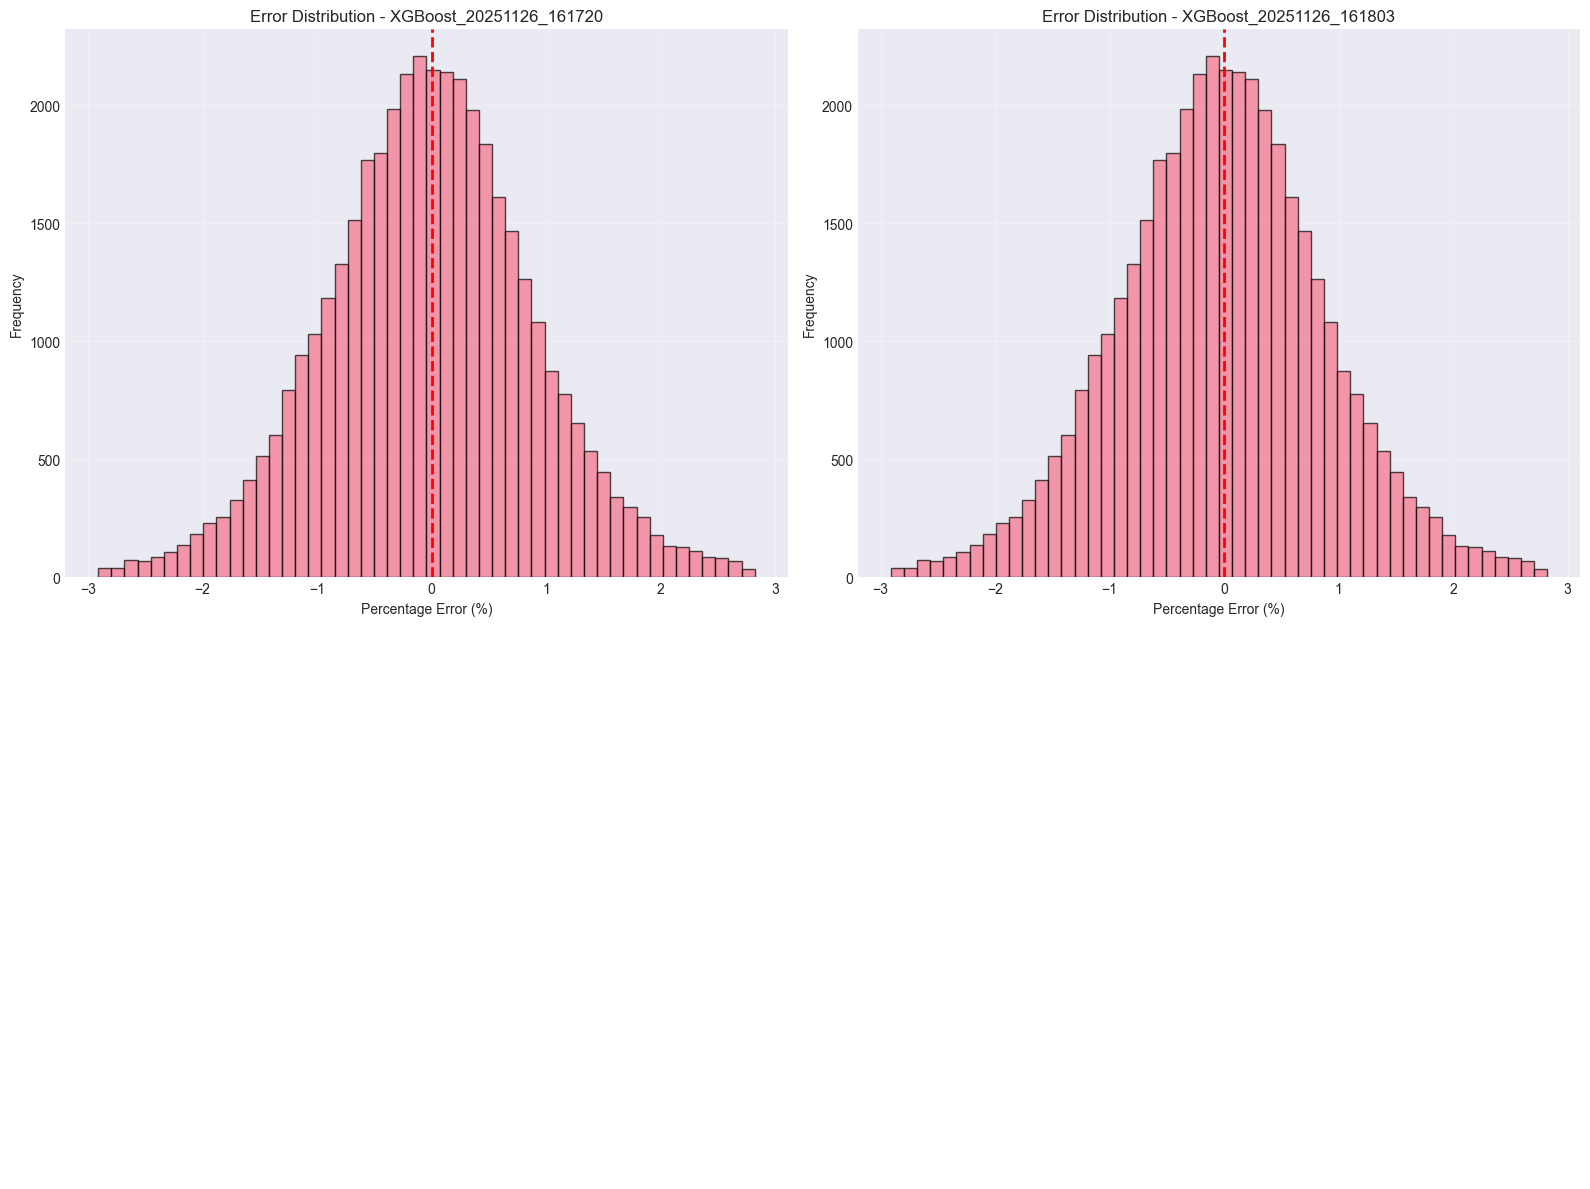

✓ Error distribution plots saved


In [16]:
# 3. Error Distribution
if len(xgboost_results) > 0 and y_test is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    model_idx = 0
    for model_name, result in xgboost_results.items():
        if result['predictions'] is not None and model_idx < 4:
            row = model_idx // 2
            col = model_idx % 2
            
            predictions = result['predictions']
            errors = y_test.values - predictions
            percentage_errors = (errors / y_test.values) * 100
            
            # Remove outliers for better visualization
            q1, q3 = np.percentile(percentage_errors, [25, 75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            mask = (percentage_errors >= lower_bound) & (percentage_errors <= upper_bound)
            
            axes[row, col].hist(percentage_errors[mask], bins=50, alpha=0.7, edgecolor='black')
            axes[row, col].axvline(x=0, color='r', linestyle='--', lw=2)
            axes[row, col].set_xlabel('Percentage Error (%)')
            axes[row, col].set_ylabel('Frequency')
            axes[row, col].set_title(f'Error Distribution - {model_name}')
            axes[row, col].grid(alpha=0.3)
            
            model_idx += 1
    
    # Hide unused subplots
    for idx in range(model_idx, 4):
        row = idx // 2
        col = idx % 2
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(reports_dir / 'error_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Error distribution plots saved")


## 8. Error Analysis by Dimensions

Analyze prediction errors across different dimensions (store type, day of week, promotions, etc.).


In [23]:
# Error analysis for best model
if len(xgboost_results) > 0 and y_test is not None:
    # Get best model predictions
    best_model_name = None
    best_predictions = None
    
    if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
        best_model_name = comparison_df.iloc[0]['Model']
        if best_model_name in xgboost_results:
            best_predictions = xgboost_results[best_model_name]['predictions']
    
    if best_predictions is None:
        for model_name, result in xgboost_results.items():
            if result['predictions'] is not None:
                best_model_name = model_name
                best_predictions = result['predictions']
                break
    
    if best_predictions is not None:
        # Create analysis dataframe
        analysis_df = test_metadata.copy()
        analysis_df['Actual'] = y_test.values
        analysis_df['Predicted'] = best_predictions
        analysis_df['Error'] = analysis_df['Actual'] - analysis_df['Predicted']
        analysis_df['AbsError'] = np.abs(analysis_df['Error'])
        analysis_df['PctError'] = (analysis_df['Error'] / analysis_df['Actual']) * 100
        
        # Add features from test data for analysis
        if 'StoreType' in test_df.columns:
            analysis_df['StoreType'] = test_df['StoreType'].values
        if 'DayOfWeek' in test_df.columns:
            analysis_df['DayOfWeek'] = test_df['DayOfWeek'].values
        if 'Promo' in test_df.columns:
            analysis_df['Promo'] = test_df['Promo'].values
        if 'StateHoliday' in test_df.columns:
            analysis_df['StateHoliday'] = test_df['StateHoliday'].values
        if 'SchoolHoliday' in test_df.columns:
            analysis_df['SchoolHoliday'] = test_df['SchoolHoliday'].values
        
        print(f"\n{'='*70}")
        print(f"ERROR ANALYSIS - {best_model_name}")
        print(f"{'='*70}")
        
        # Error by Store Type
        if 'StoreType' in analysis_df.columns:
            print("\nError by Store Type:")
            store_type_errors = analysis_df.groupby('StoreType').agg({
                'AbsError': 'mean',
                'PctError': 'mean',
                'Actual': 'count'
            }).round(2)
            store_type_errors.columns = ['Mean Abs Error', 'Mean % Error', 'Count']
            print(store_type_errors)
        
        # Error by Day of Week
        if 'DayOfWeek' in analysis_df.columns:
            print("\nError by Day of Week:")
            dow_errors = analysis_df.groupby('DayOfWeek').agg({
                'AbsError': 'mean',
                'PctError': 'mean',
                'Actual': 'count'
            }).round(2)
            dow_errors.columns = ['Mean Abs Error', 'Mean % Error', 'Count']
            print(dow_errors)
        
        # Error by Promotion
        if 'Promo' in analysis_df.columns:
            print("\nError by Promotion Status:")
            promo_errors = analysis_df.groupby('Promo').agg({
                'AbsError': 'mean',
                'PctError': 'mean',
                'Actual': 'count'
            }).round(2)
            promo_errors.columns = ['Mean Abs Error', 'Mean % Error', 'Count']
            promo_errors.index = ['No Promo', 'Promo']
            print(promo_errors)
        
        # Error by Holiday
        if 'StateHoliday' in analysis_df.columns:
            print("\nError by State Holiday:")
            holiday_errors = analysis_df.groupby('StateHoliday').agg({
                'AbsError': 'mean',
                'PctError': 'mean',
                'Actual': 'count'
            }).round(2)
            holiday_errors.columns = ['Mean Abs Error', 'Mean % Error', 'Count']
            print(holiday_errors)
        
        print(f"\n{'='*70}")
        
    else:
        print("⚠ No predictions available for error analysis")
else:
    print("⚠ Cannot perform error analysis - no models or target data available")



ERROR ANALYSIS - XGBoost_20251126_161720

Error by Store Type:
           Mean Abs Error  Mean % Error  Count
StoreType                                     
a                   53.02           NaN  25886
b                  148.64         -0.15    731
c                   43.40           NaN   6364
d                   43.22           NaN  14964

Error by Day of Week:
           Mean Abs Error  Mean % Error  Count
DayOfWeek                                     
1                   74.58           NaN   6690
2                   61.03           NaN   6690
3                   49.68           NaN   6690
4                   48.78           NaN   6690
5                   53.67           NaN   7805
6                   55.32           NaN   6690
7                    7.36           NaN   6690

Error by Promotion Status:
          Mean Abs Error  Mean % Error  Count
No Promo           39.06           NaN  30105
Promo              68.85           NaN  17840

Error by State Holiday:
              Mea

In [ ]:
# Feature importance for XGBoost models (FIXED)
if len(xgboost_results) > 0:
    # Get best model
    best_model_name = None
    best_model = None
    best_model_metadata = None
    
    if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
        best_model_name = comparison_df.iloc[0]['Model']
        if best_model_name in xgboost_results:
            best_model = xgboost_results[best_model_name]['model']
            best_model_metadata = xgboost_results[best_model_name].get('metadata', {})
    
    if best_model is None:
        for model_name, result in xgboost_results.items():
            if result['model'] is not None:
                best_model_name = model_name
                best_model = result['model']
                best_model_metadata = result.get('metadata', {})
                break
    
    if best_model is not None and hasattr(best_model, 'feature_importances_'):
        # Get feature names - try multiple sources
        feature_names = None
        
        # Try 1: Get from model's booster
        try:
            feature_names = best_model.get_booster().feature_names
            print(f"✓ Got feature names from model booster: {len(feature_names)} features")
        except Exception as e:
            print(f"ℹ Could not get feature names from booster: {e}")
        
        # Try 2: Get from metadata
        if feature_names is None and best_model_metadata and 'feature_names' in best_model_metadata:
            feature_names = best_model_metadata['feature_names']
            print(f"✓ Got feature names from metadata: {len(feature_names)} features")
        
        # Try 3: Use X_test columns (fallback)
        if feature_names is None:
            feature_names = list(X_test.columns)
            print(f"ℹ Using X_test columns as fallback: {len(feature_names)} features")
        
        # Ensure we have the right number of features
        n_features = len(best_model.feature_importances_)
        print(f"Model has {n_features} feature importances")
        
        if len(feature_names) != n_features:
            print(f"⚠ Feature count mismatch: {len(feature_names)} feature names vs {n_features} importances")
            # If mismatch, use first n_features from feature_names
            if len(feature_names) > n_features:
                feature_names = feature_names[:n_features]
                print(f"  Using first {n_features} features")
            else:
                # If not enough, pad with generic names
                feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features)]
                print(f"  Padded to {n_features} features")
        
        # Get feature importance
        feature_importance = pd.DataFrame({
            'feature': feature_names[:n_features],
            'importance': best_model.feature_importances_
        })
        feature_importance = feature_importance.sort_values('importance', ascending=False)
        
        # Display top 20 features
        print(f"\n{'='*70}")
        print(f"TOP 20 FEATURE IMPORTANCE - {best_model_name}")
        print(f"{'='*70}")
        print(feature_importance.head(20).to_string(index=False))
        
        # Visualize top features
        plt.figure(figsize=(12, 8))
        top_n = 20
        top_features = feature_importance.head(top_n)
        
        plt.barh(range(len(top_features)), top_features['importance'].values)
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importance - {best_model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(reports_dir / 'feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✓ Feature importance plot saved")
        
        # Save feature importance
        importance_path = MODELS_DIR / f'{best_model_name}_feature_importance.csv'
        feature_importance.to_csv(importance_path, index=False)
        print(f"✓ Feature importance saved to: {importance_path}")
        
    else:
        print("⚠ Feature importance not available for this model type")
else:
    print("⚠ No models available for feature importance analysis")


In [ ]:
# Feature importance for XGBoost models (FIXED VERSION)
if len(xgboost_results) > 0:
    # Get best model
    best_model_name = None
    best_model = None
    best_model_metadata = None
    
    if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
        best_model_name = comparison_df.iloc[0]['Model']
        if best_model_name in xgboost_results:
            best_model = xgboost_results[best_model_name]['model']
            best_model_metadata = xgboost_results[best_model_name].get('metadata', {})
    
    if best_model is None:
        for model_name, result in xgboost_results.items():
            if result['model'] is not None:
                best_model_name = model_name
                best_model = result['model']
                best_model_metadata = result.get('metadata', {})
                break
    
    if best_model is not None and hasattr(best_model, 'feature_importances_'):
        # Get feature names - try multiple sources
        feature_names = None
        
        # Try 1: Get from model's booster
        try:
            feature_names = best_model.get_booster().feature_names
            print(f"✓ Got feature names from model booster: {len(feature_names)} features")
        except Exception as e:
            print(f"ℹ Could not get feature names from booster: {e}")
        
        # Try 2: Get from metadata
        if feature_names is None and best_model_metadata and 'feature_names' in best_model_metadata:
            feature_names = best_model_metadata['feature_names']
            print(f"✓ Got feature names from metadata: {len(feature_names)} features")
        
        # Try 3: Use X_test columns (fallback)
        if feature_names is None:
            feature_names = list(X_test.columns)
            print(f"ℹ Using X_test columns as fallback: {len(feature_names)} features")
        
        # Ensure we have the right number of features
        n_features = len(best_model.feature_importances_)
        print(f"Model has {n_features} feature importances")
        
        if len(feature_names) != n_features:
            print(f"⚠ Feature count mismatch: {len(feature_names)} feature names vs {n_features} importances")
            # If mismatch, use first n_features from feature_names
            if len(feature_names) > n_features:
                feature_names = feature_names[:n_features]
                print(f"  Using first {n_features} features")
            else:
                # If not enough, pad with generic names
                feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features)]
                print(f"  Padded to {n_features} features")
        
        # Get feature importance
        feature_importance = pd.DataFrame({
            'feature': feature_names[:n_features],
            'importance': best_model.feature_importances_
        })
        feature_importance = feature_importance.sort_values('importance', ascending=False)
        
        # Display top 20 features
        print(f"\n{'='*70}")
        print(f"TOP 20 FEATURE IMPORTANCE - {best_model_name}")
        print(f"{'='*70}")
        print(feature_importance.head(20).to_string(index=False))
        
        # Visualize top features
        plt.figure(figsize=(12, 8))
        top_n = 20
        top_features = feature_importance.head(top_n)
        
        plt.barh(range(len(top_features)), top_features['importance'].values)
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importance - {best_model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(reports_dir / 'feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✓ Feature importance plot saved")
        
        # Save feature importance
        importance_path = MODELS_DIR / f'{best_model_name}_feature_importance.csv'
        feature_importance.to_csv(importance_path, index=False)
        print(f"✓ Feature importance saved to: {importance_path}")
        
    else:
        print("⚠ Feature importance not available for this model type")
else:
    print("⚠ No models available for feature importance analysis")


## 10. Summary and Recommendations

Provide a comprehensive summary and recommendations for model selection.


In [20]:
print("\n" + "="*80)
print("MODEL EVALUATION SUMMARY")
print("="*80)

# Summary statistics
print(f"\n Evaluation Statistics:")
print(f"   - Total models evaluated: {len(xgboost_results) + len(lstm_results)}")
print(f"   - XGBoost models: {len(xgboost_results)}")
print(f"   - LSTM models: {len(lstm_results)}")
print(f"   - Test samples: {len(X_test):,}")

# Best model recommendation
if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
    best_model = comparison_df.iloc[0]
    print(f"\n RECOMMENDED MODEL: {best_model['Model']}")
    print(f"\n   Performance Metrics:")
    print(f"   - RMSPE: {best_model['RMSPE']:.4f}%")
    print(f"   - RMSE: {best_model['RMSE']:.4f}")
    print(f"   - MAE: {best_model['MAE']:.4f}")
    print(f"   - R²: {best_model['R²']:.4f}")
    
    # Check if meets business objective
    if best_model['RMSPE'] < 10:
        print(f"\n    Meets business objective (RMSPE < 10%)")
    else:
        print(f"\n   ⚠ Does not meet business objective (RMSPE < 10%)")
        print(f"      Current RMSPE: {best_model['RMSPE']:.4f}%")
        print(f"      Target: < 10%")
        print(f"      Gap: {best_model['RMSPE'] - 10:.4f}%")
    
    print(f"\n Recommendations:")
    print(f"   1. Use {best_model['Model']} for production deployment")
    print(f"   2. Monitor model performance over time")
    print(f"   3. Retrain model periodically with new data")
    print(f"   4. Consider ensemble methods if further improvement needed")
    
    # Model comparison insights
    if len(comparison_df) > 1:
        print(f"\n Model Comparison Insights:")
        rmspe_range = comparison_df['RMSPE'].max() - comparison_df['RMSPE'].min()
        print(f"   - RMSPE range: {rmspe_range:.4f}%")
        print(f"   - Best model improvement: {rmspe_range:.4f}% over worst model")
        
        if 'R²' in comparison_df.columns:
            r2_range = comparison_df['R²'].max() - comparison_df['R²'].min()
            print(f"   - R² range: {r2_range:.4f}")
else:
    print("\n⚠ No model comparison available")

print(f"\n{'='*80}")
print("Evaluation Complete!")
print(f"{'='*80}")

# Save summary
best_model_name = None
best_rmspe_value = None
if len(comparison_df) > 0 and 'RMSPE' in comparison_df.columns:
    best_model_name = comparison_df.iloc[0]['Model']
    best_rmspe_value = comparison_df.iloc[0]['RMSPE']

summary = {
    'evaluation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'models_evaluated': len(xgboost_results) + len(lstm_results),
    'test_samples': len(X_test),
    'best_model': best_model_name,
    'best_rmspe': best_rmspe_value
}

summary_path = MODELS_DIR / 'evaluation_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n✓ Evaluation summary saved to: {summary_path}")



MODEL EVALUATION SUMMARY

 Evaluation Statistics:
   - Total models evaluated: 5
   - XGBoost models: 2
   - LSTM models: 3
   - Test samples: 47,945

 RECOMMENDED MODEL: XGBoost_20251126_161720

   Performance Metrics:
   - RMSPE: 1.3966%
   - RMSE: 140.4910
   - MAE: 57.5786
   - R²: 0.9979

    Meets business objective (RMSPE < 10%)

 Recommendations:
   1. Use XGBoost_20251126_161720 for production deployment
   2. Monitor model performance over time
   3. Retrain model periodically with new data
   4. Consider ensemble methods if further improvement needed

 Model Comparison Insights:
   - RMSPE range: 0.0000%
   - Best model improvement: 0.0000% over worst model
   - R² range: 0.0000

Evaluation Complete!

✓ Evaluation summary saved to: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/models/evaluation_summary.json
